# Mean Shift

**Mean Shift** — это ещё один метод кластеризации в Machine Learning, который не требует заранее задавать число кластеров. В отличие от DBSCAN, он основан не на плотностных порогах, а на поиске максимумов плотности (мод) в распределении данных.

Mean Shift рассматривает точки как выборку из некоторого распределения и пытается найти области, где плотность максимальна. Он «сдвигает» точки в сторону ближайшего пика плотности, пока не достигнет локального максимума.

**Алгоритм**

1. Для каждой точки выбирается окно (обычно радиус bandwidth)
2. Внутри окна вычисляется среднее положение всех точек
3. Центр окна сдвигается в это среднее
4. Процесс повторяется до сходимости (когда сдвиг становится очень маленьким)
5. Точки, сошедшиеся к одному и тому же максимуму, образуют кластер

# Используемые библиотеки

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MeanShift
from sklearn.metrics import silhouette_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import mode

# Описание и демонстрация датасета

**Iris dataset** — это классический датасет для задач классификации и кластеризации, широко используемый в машинном обучении.

Датасет содержит измерения цветов ириса трёх различных видов:

* Iris setosa
* Iris versicolor
* Iris virginica

In [2]:
data = load_iris()

X = data.data
y = data.target

feature_names = data.feature_names
target_names = data.target_names

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [4]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


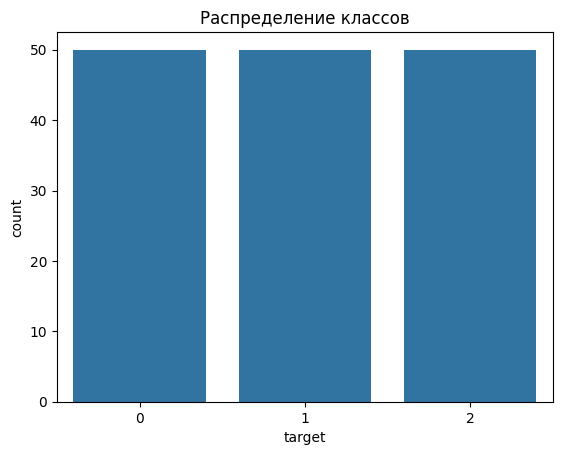

In [5]:
sns.countplot(x='target', data=df)
plt.title('Распределение классов')
plt.show()

# Препроцессинг датасета

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Обучение модели

**Метод локтя** — это способ определения оптимального количества кластеров (k) в алгоритме K-Means.

**Основная идея**

При увеличении числа кластеров:

* модель лучше подстраивается под данные
* расстояние точек до центров уменьшается

Но после некоторого момента улучшение становится незначительным. Этот «перелом» на графике и называется локтем

In [7]:
from sklearn.cluster import MeanShift, estimate_bandwidth

bandwidth = estimate_bandwidth(
    X_scaled,
    quantile=0.2,   # главный параметр
    n_samples=500
)

print("Estimated bandwidth:", bandwidth)

Estimated bandwidth: 1.207017869625092


In [8]:
meanshift = MeanShift(bandwidth=0.97)
y_ms = meanshift.fit_predict(X_scaled)

# Оценка качества

In [9]:
score = silhouette_score(X_scaled, y_ms)
print("Silhouette Score:", score)

Silhouette Score: 0.39649384320162395


# Визуализация результатов

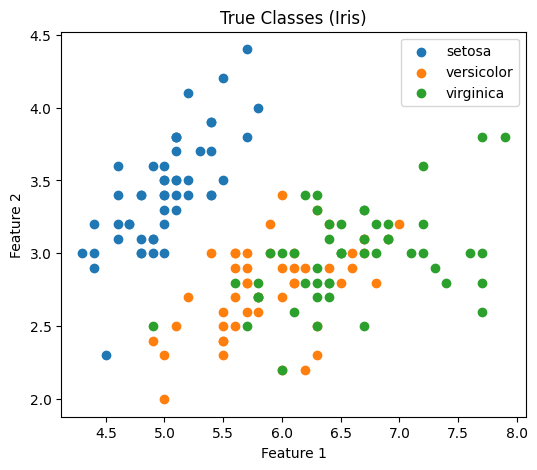

In [10]:
plt.figure(figsize=(6,5))

for cls in np.unique(y):
    plt.scatter(
        X[y == cls, 0],
        X[y == cls, 1],
        label=data.target_names[cls]
    )

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("True Classes (Iris)")
plt.legend()
plt.show()

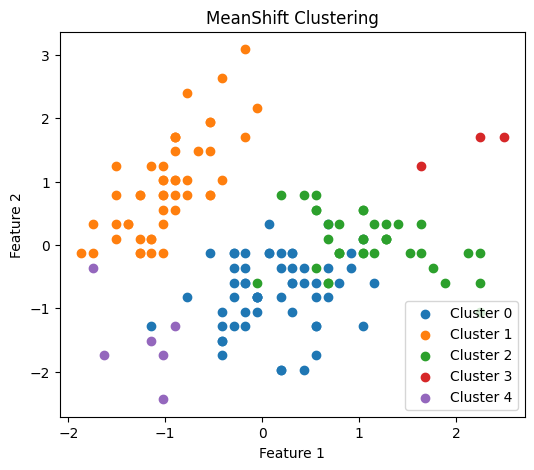

In [11]:
plt.figure(figsize=(6,5))

for cluster in np.unique(y_ms):
    plt.scatter(
        X_scaled[y_ms == cluster, 0],
        X_scaled[y_ms == cluster, 1],
        label=f"Cluster {cluster}"
    )

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("MeanShift Clustering")
plt.legend()
plt.show()

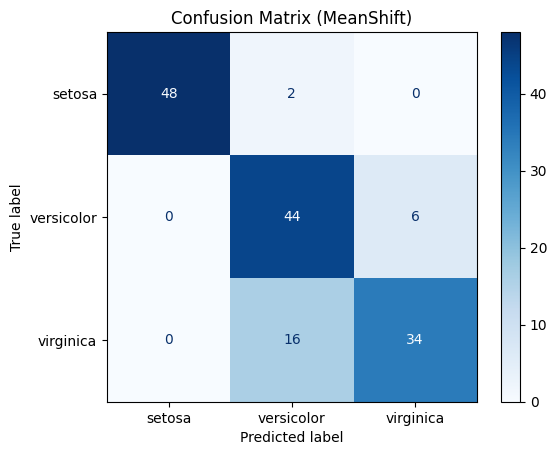

In [12]:
y_ms_mapped = np.zeros_like(y_ms)

for cluster in np.unique(y_ms):
    mask = (y_ms == cluster)
    y_ms_mapped[mask] = mode(y[mask], keepdims=True).mode[0]

cm = confusion_matrix(y, y_ms_mapped)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names
)

disp.plot(cmap='Blues')
plt.title('Confusion Matrix (MeanShift)')
plt.show()